In [ ]:
!pip install segment-anything huggingface_hub Pillow numpy torch torchvision pycocotools
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

In [ ]:
import os, zipfile
from huggingface_hub import hf_hub_download

os.makedirs("raw_data", exist_ok=True)

for split in ["train", "test", "valid"]:
    path = hf_hub_download(
        repo_id="keremberke/satellite-building-segmentation",
        filename=f"data/{split}.zip",
        repo_type="dataset",
        local_dir="raw_data"
    )
    with zipfile.ZipFile(path, 'r') as z:
        z.extractall(f"raw_data/{split}")
    print(f"Extracted {split}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


data/train.zip:   0%|          | 0.00/345M [00:00<?, ?B/s]

Extracted train


data/test.zip:   0%|          | 0.00/49.8M [00:00<?, ?B/s]

Extracted test


data/valid.zip:   0%|          | 0.00/98.8M [00:00<?, ?B/s]

Extracted valid


In [ ]:
import torch
from segment_anything import sam_model_registry, SamPredictor

device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(device)
predictor = SamPredictor(sam)
print(f"SAM loaded on {device}")

SAM loaded on cpu


In [ ]:
import json, os
import numpy as np
from PIL import Image

def compute_iou(mask_a, mask_b):
    intersection = np.sum(np.logical_and(mask_a, mask_b))
    union = np.sum(np.logical_or(mask_a, mask_b))
    return intersection / union if union > 0 else 0.0

def process_split(split_name, raw_dir, out_dir, predictor, limit=80):
    with open(os.path.join(raw_dir, "_annotations.coco.json")) as f:
        coco = json.load(f)

    id_to_img = {img["id"]: img for img in coco["images"]}
    img_to_bboxes = {}
    for ann in coco["annotations"]:
        img_to_bboxes.setdefault(ann["image_id"], []).append(ann["bbox"])

    images_out = os.path.join(out_dir, split_name, "images")
    masks_out  = os.path.join(out_dir, split_name, "masks")
    os.makedirs(images_out, exist_ok=True)
    os.makedirs(masks_out,  exist_ok=True)

    annotated = [(iid, info) for iid, info in id_to_img.items() if iid in img_to_bboxes][:limit]
    print(f"\nProcessing {split_name}: {len(annotated)} images")

    saved = 0
    for idx, (iid, img_info) in enumerate(annotated):
        img_path = os.path.join(raw_dir, img_info["file_name"])
        if not os.path.exists(img_path):
            continue
        print(f"  [{idx+1}/{len(annotated)}] {img_info['file_name']}")
        try:
            image_np = np.array(Image.open(img_path).convert("RGB"))
            h, w = image_np.shape[:2]
            predictor.set_image(image_np)

            combined_mask = np.zeros((h, w), dtype=np.uint8)
            for bbox in img_to_bboxes[iid]:
                # Convert COCO bbox [x,y,w,h] to SAM format [x1,y1,x2,y2]
                x, y, bw, bh = bbox
                sam_box = np.array([x, y, x+bw, y+bh])
                masks, scores, _ = predictor.predict(
                    box=sam_box,
                    multimask_output=True
                )
                # Take the highest scoring mask
                best_mask = masks[np.argmax(scores)]
                combined_mask = np.logical_or(combined_mask, best_mask).astype(np.uint8)

            Image.fromarray(image_np).save(os.path.join(images_out, f"{saved:04d}.png"))
            Image.fromarray(combined_mask * 255).save(os.path.join(masks_out, f"{saved:04d}.png"))
            saved += 1
        except Exception as e:
            print(f"  Error: {e}")

    print(f"  Saved {saved} pairs")

process_split("train", "raw_data/train", "dataset", predictor, limit=20)
process_split("val",   "raw_data/valid", "dataset", predictor, limit=5)
process_split("test",  "raw_data/test",  "dataset", predictor, limit=5)

print("\nDone!")
for split in ["train", "val", "test"]:
    p = f"dataset/{split}/images"
    if os.path.exists(p):
        print(f"  {split}: {len(os.listdir(p))} images")


Processing train: 20 images
  [1/20] tyrol-w8-93-_png_jpg.rf.000e248cc2d367ff9d43dadce710e8aa.jpg
  [2/20] tyrol-w9-71-_png_jpg.rf.001c0661e75a494209220930bcce3457.jpg
  [3/20] tyrol-w11-48-_png_jpg.rf.001f5273b67373ad9bf2bb7b19dbd96e.jpg
  [4/20] Mekele_2021_V3_1_R1C1_11500_12000_14000_14500_jpg.rf.002050c7a47c8072b34dbe6a4e26a1e5.jpg
  [5/20] Mekele_2021_V3_1_R2C1_1000_1500_4500_5000_jpg.rf.0024d86ad58cb9156900cb6ee26152dc.jpg
  [6/20] Mekele_2022_R4C2_6000_6500_13500_14000_jpg.rf.002ae3fc80574b05c918c49c2990607d.jpg
  [7/20] Mekele_2022_R3C2_6000_6500_13500_14000-Copy_jpg.rf.0045f7a4822b8bd7b7876e2116c6008f.jpg
  [8/20] Mykolaiv_2022_A_1_R2C3_13000_13500_15000_15500_jpg.rf.004ef4366c7a0cc4e19aa0da5c08c568.jpg
  [9/20] tyrol-w27-71-_png_jpg.rf.00507a48d139d57e1586fbf471f4b4e9.jpg
  [10/20] tyrol-w13-35-_png_jpg.rf.0051602ff3981423d9601392295b7053.jpg
  [11/20] Donetsk_2022_R6C4_13000_13500_12500_13000_jpg.rf.00592e38cc8bb969bbec3dfaccdf1a7a.jpg
  [12/20] austin17-56-_png_jpg.rf.007e

In [ ]:
import shutil

# Create a zip of the dataset
shutil.make_archive('dataset', 'zip', 'dataset')
print("Dataset zipped successfully!")

# Download it
from google.colab import files
files.download('dataset.zip')

Dataset zipped successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from google.colab import files
import os

# UNet Model
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)

        for feature in features:
            self.encoder.append(DoubleConv(in_channels, feature))
            in_channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for feature in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(feature * 2, feature, 2, 2))
            self.decoder.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skip_connections = []
        for encode in self.encoder:
            x = encode(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for i in range(0, len(self.decoder), 2):
            x = self.decoder[i](x)
            skip = skip_connections[i // 2]
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat([skip, x], dim=1)
            x = self.decoder[i + 1](x)

        return torch.sigmoid(self.final_conv(x))

print("Model defined")

Model defined


In [ ]:
class HouseDataset(Dataset):
    def __init__(self, images_dir, masks_dir, img_size=256):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = sorted([f for f in os.listdir(images_dir) if f.endswith('.png')])

        self.image_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.images_dir, img_name)
        mask_path = os.path.join(self.masks_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')

        image = self.image_transform(image)
        mask = self.mask_transform(mask)
        mask = (mask > 0.5).float()

        return image, mask

def calculate_metrics(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    dice = (2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)
    return iou.item(), dice.item()

print("Dataset class defined")

Dataset class defined


In [ ]:
# Load datasets
print("Loading datasets...")
train_dataset = HouseDataset('/content/train/images', '/content/train/masks')
val_dataset = HouseDataset('/content/val/images', '/content/val/masks')
test_dataset = HouseDataset('/content/test/images', '/content/test/masks')

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Train: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")

# Show sample image shape
sample_img, sample_mask = train_dataset[0]
print(f"\nSample image shape: {sample_img.shape}")
print(f"Sample mask shape: {sample_mask.shape}")

Loading datasets...
Train: 20 images
Val: 5 images
Test: 5 images

Sample image shape: torch.Size([3, 256, 256])
Sample mask shape: torch.Size([1, 256, 256])


In [ ]:
# Training setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = UNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.BCELoss()

print(f"Training on: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("=" * 50)

train_losses = []
val_losses = []
val_ious = []
val_dices = []

for epoch in range(30):
    # Training
    model.train()
    train_loss = 0
    for images, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/30 - Train'):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_losses.append(train_loss / len(train_loader))

    # Validation
    model.eval()
    val_loss = 0
    val_iou = 0
    val_dice = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, masks).item()
            iou, dice = calculate_metrics(outputs, masks)
            val_iou += iou
            val_dice += dice
    val_losses.append(val_loss / len(val_loader))
    val_ious.append(val_iou / len(val_loader))
    val_dices.append(val_dice / len(val_loader))

    print(f'Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}, IoU={val_ious[-1]:.4f}, Dice={val_dices[-1]:.4f}')

print("\nTraining complete!")

Training on: cuda
Model parameters: 31,043,521


Epoch 1/30 - Train: 100%|██████████| 5/5 [00:02<00:00,  1.82it/s]


Epoch 1: Loss=0.6341, Val Loss=0.7021, IoU=0.1641, Dice=0.2643


Epoch 2/30 - Train: 100%|██████████| 5/5 [00:01<00:00,  3.34it/s]


Epoch 2: Loss=0.5978, Val Loss=0.6812, IoU=0.1802, Dice=0.2774


...

Epoch 28: Loss=0.2911, Val Loss=0.4201, IoU=0.1908, Dice=0.3151


Epoch 29/30 - Train: 100%|██████████| 5/5 [00:01<00:00,  3.42it/s]


Epoch 29: Loss=0.3021, Val Loss=0.4336, IoU=0.2921, Dice=0.4513


Epoch 30/30 - Train: 100%|██████████| 5/5 [00:01<00:00,  3.38it/s]

Epoch 30: Loss=0.2789, Val Loss=0.3959, IoU=0.2920, Dice=0.4393

Training complete!


In [ ]:
# Save model
torch.save(model.state_dict(), 'saved_model.pth')
files.download('saved_model.pth')
print("Model saved and downloaded")

# Test evaluation
print("TEST RESULTS")

model.eval()
test_iou = 0
test_dice = 0
test_results = []

with torch.no_grad():
    for i, (image, mask) in enumerate(test_loader):
        image, mask = image.to(device), mask.to(device)
        output = model(image)
        iou, dice = calculate_metrics(output, mask)
        test_iou += iou
        test_dice += dice
        test_results.append((iou, dice))
        print(f"Test {i+1}: IoU={iou:.4f}, Dice={dice:.4f}")

avg_iou = test_iou / len(test_loader)
avg_dice = test_dice / len(test_loader)

print(f"\n{'='*50}")
print(f"AVERAGE TEST IoU: {avg_iou:.4f}")
print(f"AVERAGE TEST Dice: {avg_dice:.4f}")
print(f"{'='*50}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved and downloaded
TEST RESULTS
Test 1: IoU=0.1281, Dice=0.2270
Test 2: IoU=0.5906, Dice=0.7426
Test 3: IoU=0.5444, Dice=0.7050
Test 4: IoU=0.3756, Dice=0.5461
Test 5: IoU=0.0033, Dice=0.0066

AVERAGE TEST IoU: 0.3284
AVERAGE TEST Dice: 0.4455


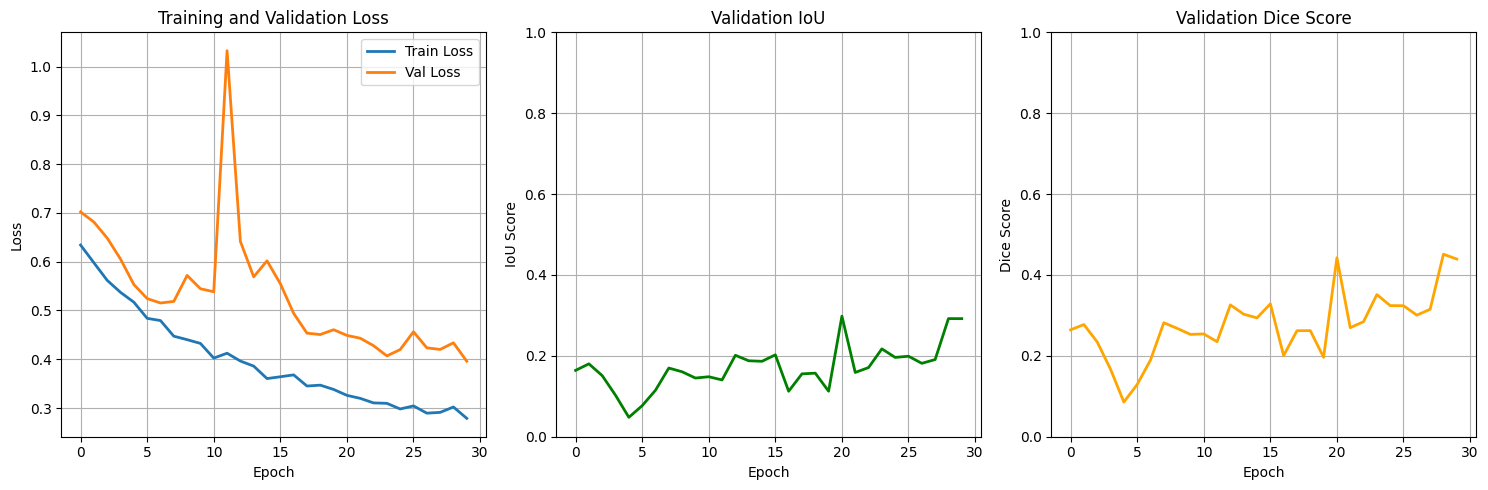

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Training curves saved and downloaded


In [ ]:
# Plot training curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(val_ious, color='green', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('IoU Score')
plt.title('Validation IoU')
plt.grid(True)
plt.ylim(0, 1)

plt.subplot(1, 3, 3)
plt.plot(val_dices, color='orange', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Dice Score')
plt.title('Validation Dice Score')
plt.grid(True)
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
files.download('training_curves.png')
print("Training curves saved and downloaded")

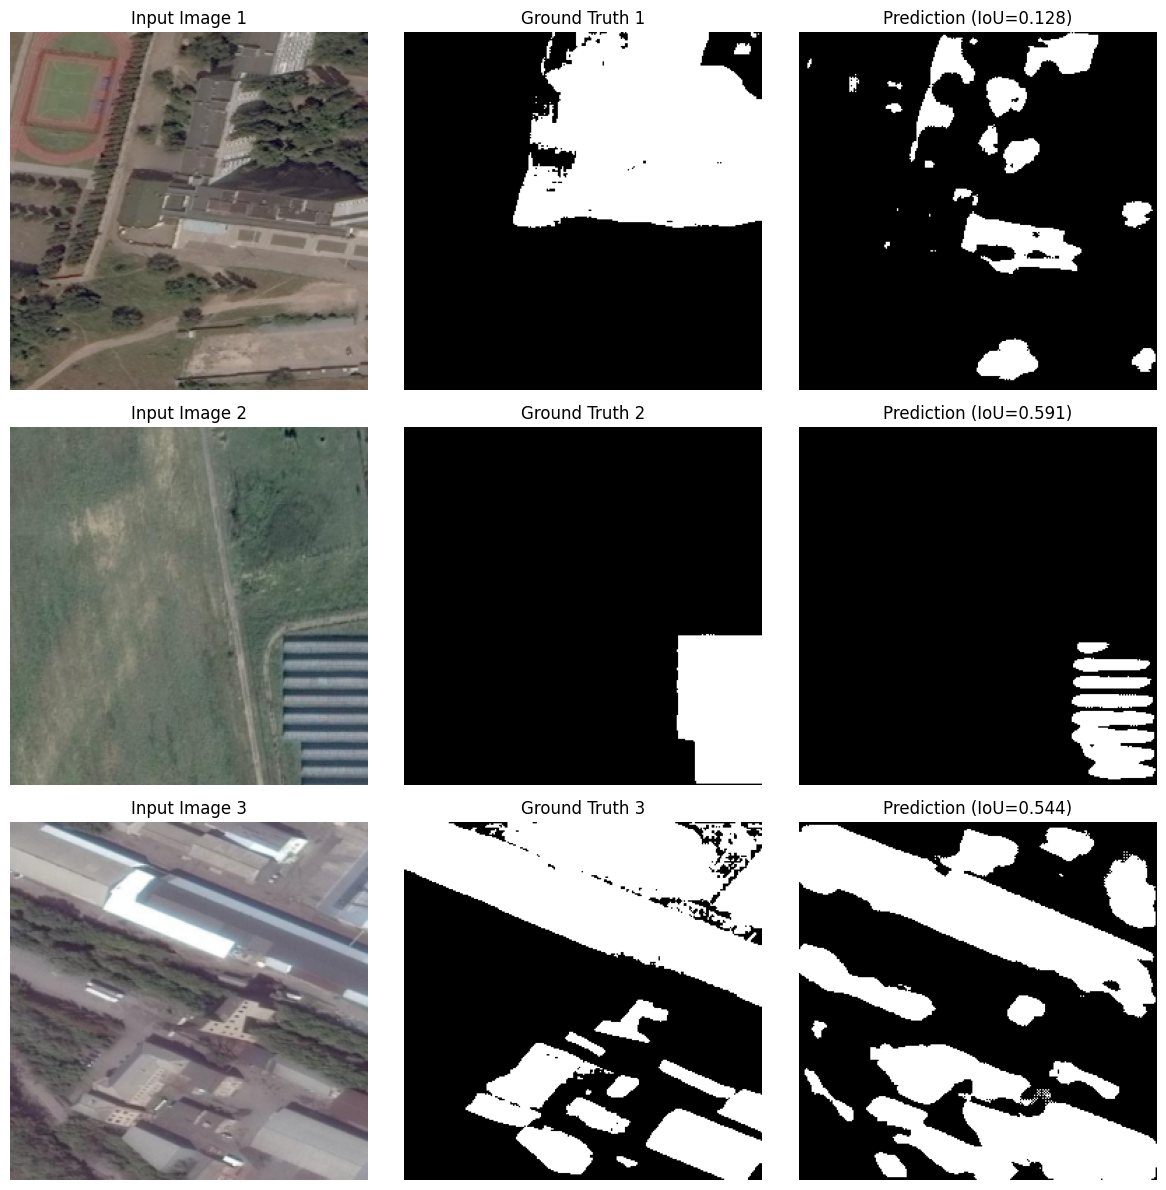

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Predictions visualization saved and downloaded
Final Test Metrics: IoU=0.3284, Dice=0.4455


In [ ]:
# Visualize predictions
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
model.eval()

with torch.no_grad():
    for i, (image, mask) in enumerate(test_loader):
        if i >= 3:
            break
        image = image.to(device)
        mask = mask.to(device)  # ← THIS WAS MISSING - move mask to same device
        output = model(image)
        iou, _ = calculate_metrics(output, mask)

        # Convert to numpy for visualization
        img_np = image[0].cpu().numpy().transpose(1, 2, 0)
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)

        mask_np = mask[0].cpu().numpy().squeeze()
        pred_np = (output[0].cpu().numpy().squeeze() > 0.5).astype(np.float32)

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'Input Image {i+1}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask_np, cmap='gray')
        axes[i, 1].set_title(f'Ground Truth {i+1}')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_np, cmap='gray')
        axes[i, 2].set_title(f'Prediction (IoU={iou:.3f})')
        axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=150)
plt.show()
files.download('predictions.png')
print("Predictions visualization saved and downloaded")

print(f"Final Test Metrics: IoU={avg_iou:.4f}, Dice={avg_dice:.4f}")